### 1. Load the dataset.


In [1]:
!pip install -q medmnist


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.6 MB/s eta 0:00:00


In [2]:
from medmnist import PathMNIST
from medmnist import INFO
from torchvision import transforms
from torch.utils.data import DataLoader

# Specify the dataset and download
data_flag = 'pathmnist'
download = True
info = INFO[data_flag]
DataClass = getattr(__import__('medmnist'), info['python_class'])

# Define transform
transform = transforms.Compose([transforms.ToTensor()])

# Load datasets
train_dataset = DataClass(split='train', transform=transform, download=download)
val_dataset = DataClass(split='val', transform=transform, download=download)
test_dataset = DataClass(split='test', transform=transform, download=download)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 206M/206M [00:12<00:00, 17.0MB/s]


### 2: Implement LeNet and MiniVGG CNNs in PyTorch

## LeNet

In [3]:
import torch.nn as nn

class LeNet(nn.Module):
    def __init__(self, num_classes=9):
        super(LeNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),  # RGB input → 3 channels
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(16 * 4 * 4, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


### MiniVGG

In [4]:
class MiniVGG(nn.Module):
    def __init__(self, num_classes=9):
        super(MiniVGG, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


## 3: Define Training and Evaluation Functions


In [5]:
import torch
import torch.nn.functional as F

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.squeeze().to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(dataloader), correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.squeeze().to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(dataloader), correct / total


4: Train for 10 Epochs and Collect Metrics

In [7]:
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, test_loader, device, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_accs, val_accs, test_accs = [], [], []
    train_losses, val_losses, test_losses = [], [], []

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        print(f"Epoch {epoch+1}/{epochs} — Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    return {
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_accs": test_accs,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "test_losses": test_losses
    }



In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# LeNet
lenet_model = LeNet().to(device)
lenet_results = train_model(lenet_model, train_loader, val_loader, test_loader, device)



Epoch 1/10 — Train Acc: 0.4086, Val Acc: 0.4868, Test Acc: 0.5357
Epoch 2/10 — Train Acc: 0.5625, Val Acc: 0.5854, Test Acc: 0.6380
Epoch 3/10 — Train Acc: 0.6102, Val Acc: 0.6165, Test Acc: 0.6556
Epoch 4/10 — Train Acc: 0.6519, Val Acc: 0.6386, Test Acc: 0.6529
Epoch 5/10 — Train Acc: 0.6790, Val Acc: 0.6827, Test Acc: 0.6706
Epoch 6/10 — Train Acc: 0.6953, Val Acc: 0.7169, Test Acc: 0.7596
Epoch 7/10 — Train Acc: 0.7080, Val Acc: 0.7295, Test Acc: 0.7173
Epoch 8/10 — Train Acc: 0.7207, Val Acc: 0.7031, Test Acc: 0.6972
Epoch 9/10 — Train Acc: 0.7253, Val Acc: 0.7483, Test Acc: 0.7404
Epoch 10/10 — Train Acc: 0.7346, Val Acc: 0.7377, Test Acc: 0.7242


In [9]:
# MiniVGG
minivgg_model = MiniVGG().to(device)
minivgg_results = train_model(minivgg_model, train_loader, val_loader, test_loader, device)


Epoch 1/10 — Train Acc: 0.5572, Val Acc: 0.6819, Test Acc: 0.7616
Epoch 2/10 — Train Acc: 0.7252, Val Acc: 0.7626, Test Acc: 0.7553
Epoch 3/10 — Train Acc: 0.7843, Val Acc: 0.8245, Test Acc: 0.8206
Epoch 4/10 — Train Acc: 0.8230, Val Acc: 0.8376, Test Acc: 0.8162
Epoch 5/10 — Train Acc: 0.8432, Val Acc: 0.8564, Test Acc: 0.8276
Epoch 6/10 — Train Acc: 0.8566, Val Acc: 0.8695, Test Acc: 0.8071
Epoch 7/10 — Train Acc: 0.8686, Val Acc: 0.8609, Test Acc: 0.8015
Epoch 8/10 — Train Acc: 0.8753, Val Acc: 0.8701, Test Acc: 0.8630
Epoch 9/10 — Train Acc: 0.8829, Val Acc: 0.8939, Test Acc: 0.8433
Epoch 10/10 — Train Acc: 0.8902, Val Acc: 0.8817, Test Acc: 0.8415


## 5: Save Model Weights

In [10]:
torch.save(lenet_model.state_dict(), "part2_lenet.pth")
torch.save(minivgg_model.state_dict(), "part2_minivgg.pth")


## 6: Visualize Results

### 1. Accuracy Curves (Train, Val, Test) for Both Architectures

In [15]:
import matplotlib.pyplot as plt

def plot_accuracies(lenet_results, minivgg_results):
    epochs = range(1, len(lenet_results["train_accs"]) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, lenet_results["train_accs"], label="LeNet - Train")
    plt.plot(epochs, lenet_results["val_accs"], label="LeNet - Val")
    plt.plot(epochs, lenet_results["test_accs"], label="LeNet - Test")

    plt.plot(epochs, minivgg_results["train_accs"], label="MiniVGG - Train")
    plt.plot(epochs, minivgg_results["val_accs"], label="MiniVGG - Val")
    plt.plot(epochs, minivgg_results["test_accs"], label="MiniVGG - Test")

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curves")
    plt.legend()
    plt.grid(True)
    plt.show()


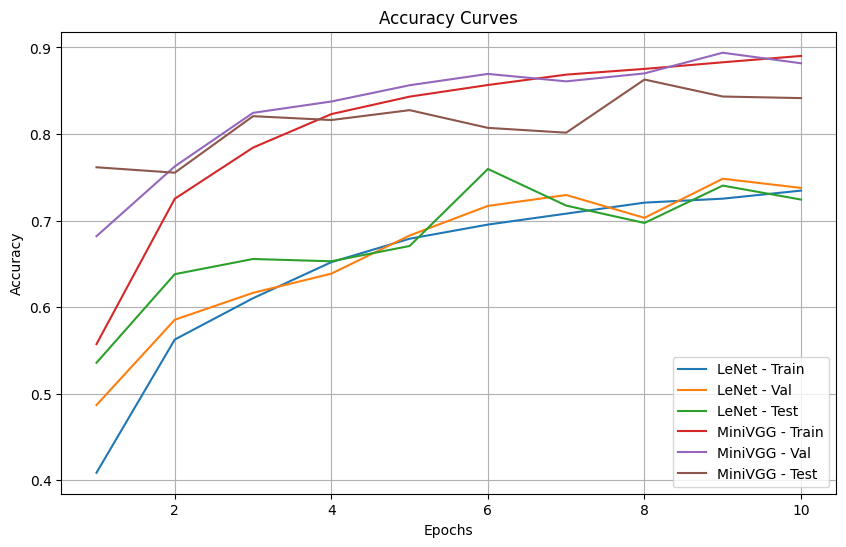

In [16]:
plot_accuracies(lenet_results, minivgg_results)

### 2. Loss Curves (Train, Val, Test) for Both Architectures

In [17]:
def plot_losses(lenet_results, minivgg_results):
    epochs = range(1, len(lenet_results["train_losses"]) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, lenet_results["train_losses"], label="LeNet - Train Loss")
    plt.plot(epochs, lenet_results["val_losses"], label="LeNet - Val Loss")
    plt.plot(epochs, lenet_results["test_losses"], label="LeNet - Test Loss")

    plt.plot(epochs, minivgg_results["train_losses"], label="MiniVGG - Train Loss")
    plt.plot(epochs, minivgg_results["val_losses"], label="MiniVGG - Val Loss")
    plt.plot(epochs, minivgg_results["test_losses"], label="MiniVGG - Test Loss")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()


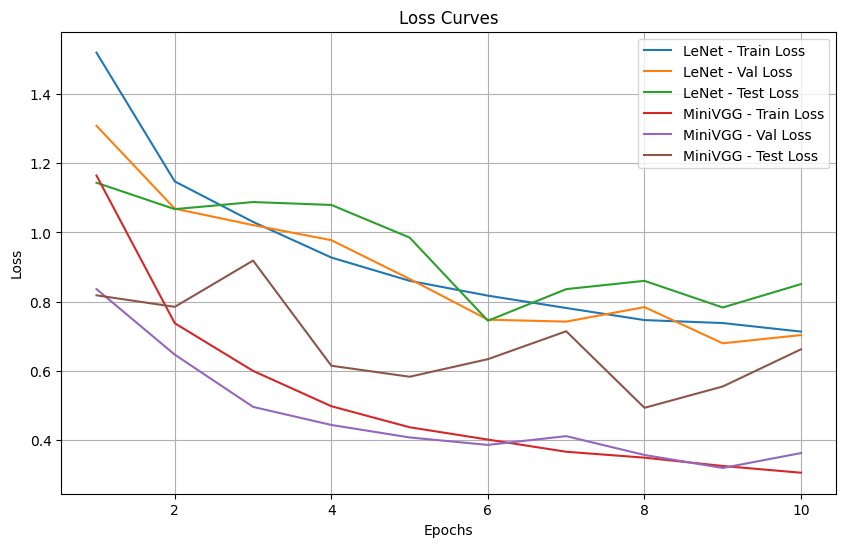

In [18]:
plot_losses(lenet_results, minivgg_results)

### 3. Confusion Matrix (on Test Set)

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataloader, device, title="Confusion Matrix"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.squeeze().cpu().numpy()
            outputs = model(images)
            preds = torch.argmax(outputs, 1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()


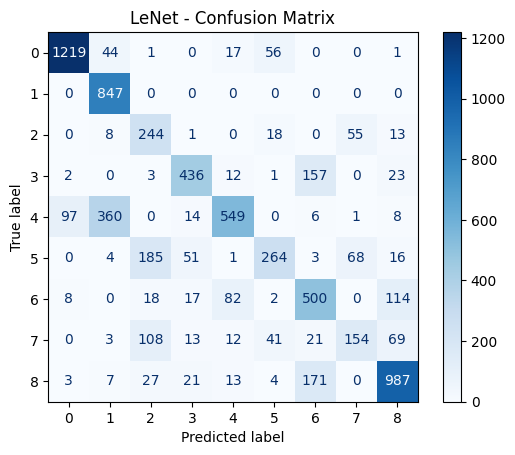

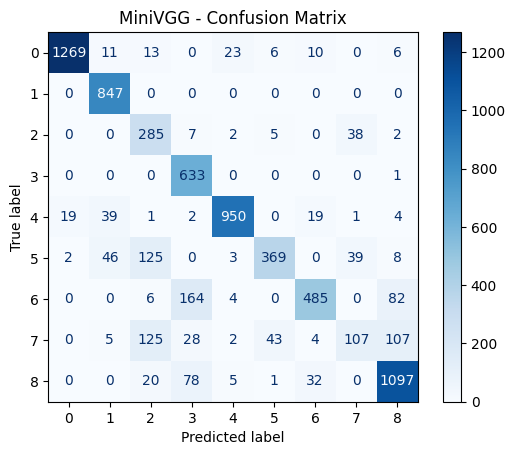

In [20]:
# Usage:
plot_confusion_matrix(lenet_model, test_loader, device, "LeNet - Confusion Matrix")
plot_confusion_matrix(minivgg_model, test_loader, device, "MiniVGG - Confusion Matrix")


### 4. Precision, Recall, F1 Score for Each Class

In [21]:
from sklearn.metrics import classification_report

def print_classification_report(model, dataloader, device, label_desc="Model"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.squeeze().cpu().numpy()
            outputs = model(images)
            preds = torch.argmax(outputs, 1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    print(f"\nClassification Report for {label_desc}")
    print(classification_report(all_labels, all_preds, digits=4))


In [22]:
# Usage:
print_classification_report(lenet_model, test_loader, device, "LeNet")
print_classification_report(minivgg_model, test_loader, device, "MiniVGG")



Classification Report for LeNet
              precision    recall  f1-score   support

           0     0.9172    0.9111    0.9141      1338
           1     0.6654    1.0000    0.7991       847
           2     0.4164    0.7198    0.5276       339
           3     0.7884    0.6877    0.7346       634
           4     0.8003    0.5304    0.6380      1035
           5     0.6839    0.4459    0.5399       592
           6     0.5828    0.6748    0.6254       741
           7     0.5540    0.3658    0.4406       421
           8     0.8018    0.8005    0.8011      1233

    accuracy                         0.7242      7180
   macro avg     0.6900    0.6818    0.6689      7180
weighted avg     0.7408    0.7242    0.7188      7180


Classification Report for MiniVGG
              precision    recall  f1-score   support

           0     0.9837    0.9484    0.9658      1338
           1     0.8935    1.0000    0.9437       847
           2     0.4957    0.8407    0.6236       339
          